# Aplicacion web de ML con Streamlit

Este notebook documenta el flujo tecnico del proyecto: seleccion del dataset Iris, entrenamiento del modelo, optimizacion, persistencia de artefactos y validacion basica de la aplicacion Streamlit.

El objetivo es entregar una app web que permita usar un modelo de Machine Learning desde una interfaz interactiva y preparada para despliegue.

## Checklist de la consigna

| Requisito | Evidencia en el repositorio |
|---|---|
| Entrenar un modelo o reutilizar uno anterior | Se reutiliza el enfoque del proyecto Flask y se entrena el modelo Iris dentro de este repo. |
| Desarrollar una app Streamlit | La interfaz principal esta en `src/app.py`. |
| Mostrar el modelo desde una web | La app recibe medidas, predice especie y muestra probabilidades. |
| Preparar despliegue | Se incluyen `requirements.txt`, `Procfile`, `render.yaml` y `.streamlit/config.toml`. |
| Documentar recursos externos | README en espanol e ingles con dataset, ejecucion y despliegue. |

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import time
import urllib.request

import joblib
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    FEATURE_COLUMNS,
    METRICS_PATH,
    MODEL_PATH,
    REPORTS_DIR,
    TARGET_COLUMN,
    load_iris_dataframe,
    predict_species,
    train_and_save_model,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\frang\OneDrive\Escritorio\Aplicaci-n-web-ML-con-el-tutorial-Streamlit-Dragcessa1998


## 1. Dataset seleccionado

Se trabaja con el **UCI Iris Dataset**, disponible desde `sklearn.datasets.load_iris`. Es un dataset pequeno y estable, ideal para centrar el proyecto en el despliegue con Streamlit sin introducir una complejidad innecesaria.

In [2]:
df = load_iris_dataframe()
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 150
Columnas: 5


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
data_dictionary = pd.DataFrame(
    [
        {"column": "sepal_length_cm", "description": "Longitud del sepalo en centimetros", "role": "feature"},
        {"column": "sepal_width_cm", "description": "Ancho del sepalo en centimetros", "role": "feature"},
        {"column": "petal_length_cm", "description": "Longitud del petalo en centimetros", "role": "feature"},
        {"column": "petal_width_cm", "description": "Ancho del petalo en centimetros", "role": "feature"},
        {"column": "species", "description": "Especie de Iris a predecir", "role": "target"},
    ]
)

data_dictionary

,column,description,role
0,sepal_length_cm,Longitud del sepalo en centimetros,feature
1,sepal_width_cm,Ancho del sepalo en centimetros,feature
2,petal_length_cm,Longitud del petalo en centimetros,feature
3,petal_width_cm,Ancho del petalo en centimetros,feature
4,species,Especie de Iris a predecir,target


## 2. Calidad y comprension de datos

Antes de entrenar el modelo se revisan tipos de datos, valores nulos, cardinalidad y distribucion de clases.

In [4]:
quality_report = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "unique_values": df.nunique(),
    }
)
quality_report

,dtype,missing_values,missing_rate,unique_values
sepal_length_cm,float64,0,0.0,35
sepal_width_cm,float64,0,0.0,23
petal_length_cm,float64,0,0.0,43
petal_width_cm,float64,0,0.0,22
species,object,0,0.0,3


In [5]:
class_distribution = df[TARGET_COLUMN].value_counts().rename_axis("species").reset_index(name="records")
class_distribution["percentage"] = (class_distribution["records"] / len(df) * 100).round(2)
class_distribution

,species,records,percentage
0,setosa,50,33.33
1,versicolor,50,33.33
2,virginica,50,33.33


In [6]:
df[FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,150.0,5.8433,0.8281,4.3,5.1,5.80,6.4,7.9
sepal_width_cm,150.0,3.0573,0.4359,2.0,2.8,3.00,3.3,4.4
petal_length_cm,150.0,3.7580,1.7653,1.0,1.6,4.35,5.1,6.9
petal_width_cm,150.0,1.1993,0.7622,0.1,0.3,1.30,1.8,2.5


## 3. Entrenamiento y optimizacion

El modelo se entrena con un pipeline compuesto por `StandardScaler` y `RandomForestClassifier`. Luego se optimizan hiperparametros con `GridSearchCV`.

In [7]:
results = train_and_save_model()
results["optimized_model"]["best_params"]

{'classifier__max_depth': 2,
 'classifier__min_samples_leaf': 1,
 'classifier__n_estimators': 80}

In [8]:
metric_columns = ["accuracy", "macro_f1"]
model_comparison = pd.DataFrame(
    [
        {"model": "baseline", **{metric: results["baseline_model"][metric] for metric in metric_columns}},
        {"model": "optimized", **{metric: results["optimized_model"][metric] for metric in metric_columns}},
    ]
)
model_comparison

,model,accuracy,macro_f1
0,baseline,0.9000,0.8997
1,optimized,0.9333,0.9333


In [9]:
confusion = pd.DataFrame(
    results["optimized_model"]["confusion_matrix"],
    index=[f"actual_{label}" for label in results["dataset"]["classes"]],
    columns=[f"pred_{label}" for label in results["dataset"]["classes"]],
)
confusion

,pred_setosa,pred_versicolor,pred_virginica
actual_setosa,10,0,0
actual_versicolor,0,9,1
actual_virginica,0,1,9


## 4. Interpretacion y visualizaciones

Las variables del petalo suelen aportar mas informacion para distinguir especies. El repositorio guarda graficos en `reports/figures/` para reforzar el analisis y el README.

In [10]:
pd.DataFrame(results["feature_importance"])

,feature,importance
0,petal_width_cm,0.4412
1,petal_length_cm,0.4271
2,sepal_length_cm,0.1309
3,sepal_width_cm,0.0008


species_distribution.png


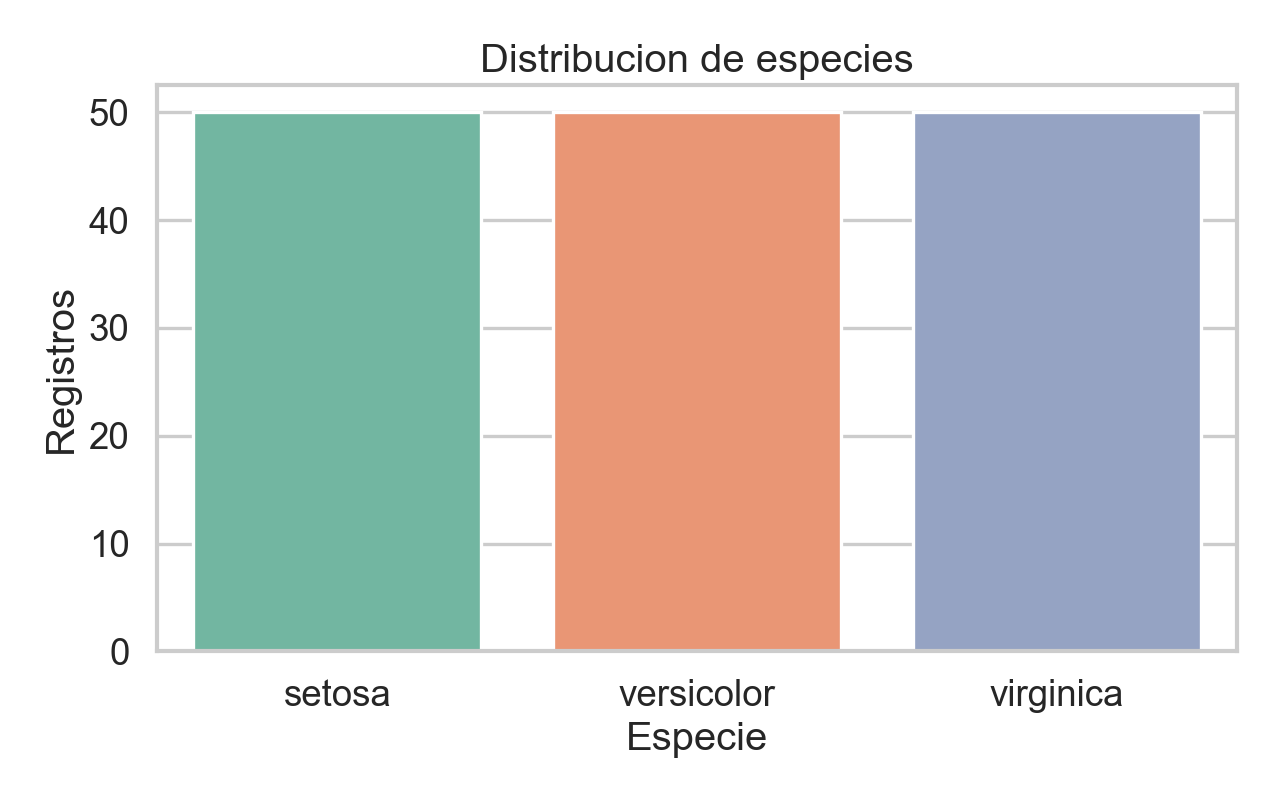

feature_importance.png


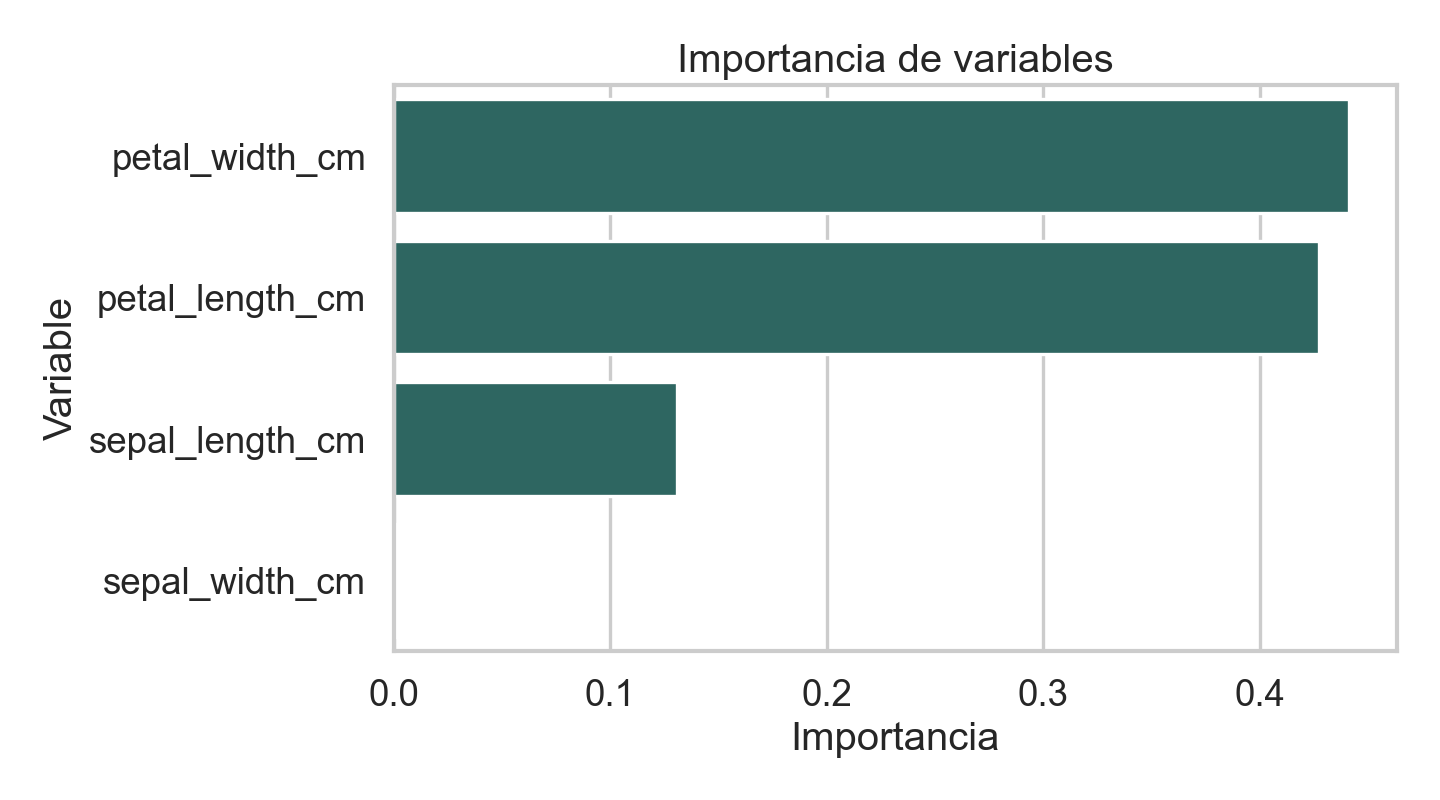

petal_scatter.png


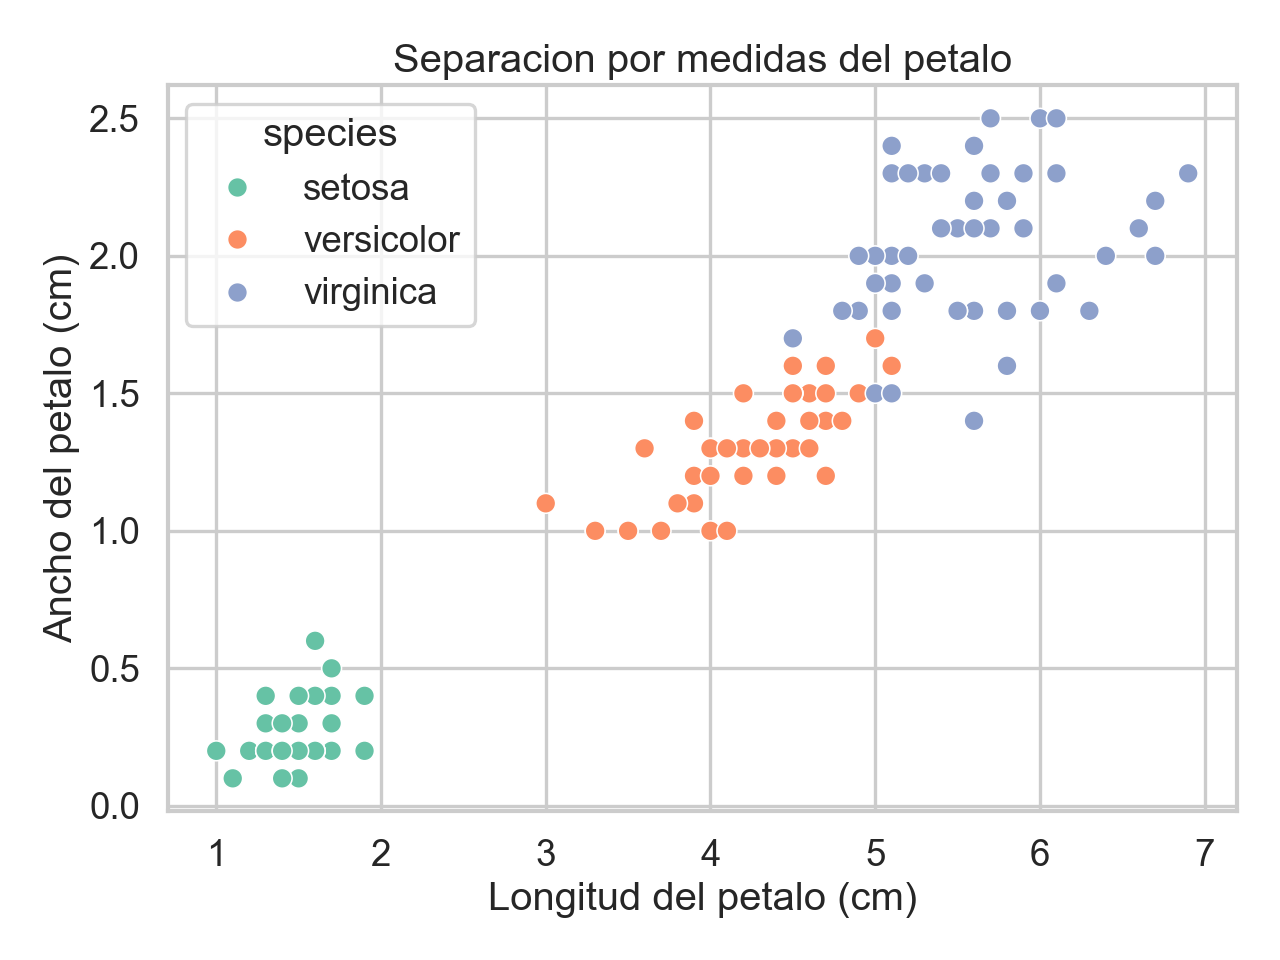

In [11]:
for figure in ["species_distribution.png", "feature_importance.png", "petal_scatter.png"]:
    print(figure)
    display(Image(filename=str(REPORTS_DIR / figure)))

## 5. Artefactos para la aplicacion

La app Streamlit no reentrena el modelo en cada interaccion. Consume un artefacto `.joblib` ya entrenado y un archivo JSON de metricas.

In [12]:
artifact_checks = []
for path in [
    PROJECT_ROOT / "data" / "raw" / "iris.csv",
    PROJECT_ROOT / "data" / "processed" / "train.csv",
    PROJECT_ROOT / "data" / "processed" / "test.csv",
    MODEL_PATH,
    METRICS_PATH,
    REPORTS_DIR / "streamlit_banner.png",
]:
    artifact_checks.append(
        {
            "artifact": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else 0,
        }
    )

pd.DataFrame(artifact_checks)

,artifact,exists,size_kb
0,data\raw\iris.csv,True,3.93
1,data\processed\train.csv,True,3.16
2,data\processed\test.csv,True,0.84
3,models\iris_classifier.joblib,True,72.98
4,models\iris_metrics.json,True,3.39
5,reports\figures\streamlit_banner.png,True,39.78


## 6. Prueba de inferencia

Se valida que el modelo guardado puede cargarse y predecir una especie a partir de las cuatro medidas usadas por la interfaz.

In [13]:
artifact = joblib.load(MODEL_PATH)
sample = {
    "sepal_length_cm": 5.8,
    "sepal_width_cm": 3.0,
    "petal_length_cm": 4.3,
    "petal_width_cm": 1.3,
}
prediction = predict_species(artifact, sample)
prediction

{'prediction': 'versicolor',
 'probabilities': {'setosa': 0.0099,
  'versicolor': 0.9179,
  'virginica': 0.0722}}

In [14]:
pd.DataFrame(prediction["probabilities"].items(), columns=["species", "probability"]).sort_values(
    "probability", ascending=False
)

,species,probability
1,versicolor,0.9179
2,virginica,0.0722
0,setosa,0.0099


## 7. Validacion tecnica de Streamlit

La validacion comprueba que el archivo principal de la app existe, que el comando de despliegue puede arrancar Streamlit y que el servidor responde con HTTP 200.

In [15]:
app_path = PROJECT_ROOT / "src" / "app.py"
assert app_path.exists(), "src/app.py no existe"

port = "8510"
process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        str(app_path),
        "--server.headless=true",
        f"--server.port={port}",
        "--server.address=127.0.0.1",
    ],
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

status_code = None
try:
    for _ in range(30):
        try:
            with urllib.request.urlopen(f"http://127.0.0.1:{port}", timeout=2) as response:
                status_code = response.status
                break
        except Exception:
            time.sleep(1)
finally:
    process.terminate()
    try:
        process.wait(timeout=8)
    except subprocess.TimeoutExpired:
        process.kill()

streamlit_validation = pd.DataFrame(
    [
        {"check": "src/app.py exists", "valid": app_path.exists(), "details": str(app_path.relative_to(PROJECT_ROOT))},
        {"check": "streamlit server response", "valid": status_code == 200, "details": status_code},
    ]
)
assert streamlit_validation["valid"].all(), "Streamlit validation failed"
streamlit_validation

,check,valid,details
0,src/app.py exists,True,src\app.py
1,streamlit server response,True,200


## 8. Preparacion para despliegue

El repositorio queda preparado para dos opciones:

- **Streamlit Community Cloud:** seleccionar `src/app.py` como archivo principal.
- **Render:** usar el comando `streamlit run src/app.py --server.port $PORT --server.address 0.0.0.0`.

In [16]:
deployment_files = [
    "requirements.txt",
    "Procfile",
    "render.yaml",
    ".streamlit/config.toml",
    "models/iris_classifier.joblib",
]

pd.DataFrame(
    [
        {"file": file, "exists": (PROJECT_ROOT / file).exists()}
        for file in deployment_files
    ]
)

,file,exists
0,requirements.txt,True
1,Procfile,True
2,render.yaml,True
3,.streamlit/config.toml,True
4,models/iris_classifier.joblib,True
